## KoChatGPT - upgrade

- foundation model : https://github.com/SKT-AI/KoGPT2
- Supervised Fine-tuning dataset : data_kochatgpt/kochatgpt_1_SFT.json : 12,000개 (질문에 잘 대답하는 모델)
- Reward Model : data_kochatgpt/kochatgpt_2_RM.json : 10,220개 (좋은 글 채점하는 모델_동일한 프롬프트에 대해 각기 다른 3가지 답변 자동생성. ranking 자동생성)
- Proximal Policy Optimization 알고리즘 : data_kochatgpt/kochatgpt_3_PPO.json: 12,000개 (RM의 점수가 높아지도록 학습_SFT에서 프롬프트만 저장)
- KoChatGPT에서 차용한 Reward Model, Proximal Policy Optimization 알고리즘의 출처 : [출처](https://github.com/hpcaitech/ColossalAI/tree/main/applications/)

학습목표
- ChatGPT 구현을 위해 필요한 데이터셋의 종류 및 특징을 설명할 수 있습니다.
- Initial Model, Reward Model, RLHF Model의 학습 로직을 설명할 수 있습니다.
  - Supervised Fine Tuning
  - Reward Model의 ranking algorithm 및 loss fuction 설계 원리
  - 언어모델을 강화학습하기 위한 방법론
- KoChatGPT를 개선해 나만의 ChatGPT를 구현할 수 있습니다.  
  
시도해볼 것
- [X] 데이터셋 정제
- [ ] 새로운 데이터셋
- [ ] foundation model 교체
- [X] 정량평가: meteor
- [X] 정성평가: 출력물 A/B 비교 평가. "어느 쪽이 더 좋은 답변인가?" 선택하기

### Setting

In [6]:
#클론
! git clone https://github.com/airobotlab/KoChatGPT
! cp -r KoChatGPT/colossalai_ChatGPT_230319/chatgpt /chatgpt

fatal: destination path 'KoChatGPT' already exists and is not an empty directory.
cp: cannot stat '/content/KoChatGPT/colossalai_ChatGPT_230319/chatgpt': No such file or directory


In [4]:
#라이브러리 설치
! pip install datasets
! pip install loralib
! pip install trl
! pip install accelerate
! pip install transformers

In [7]:
# !rm -rf chatgpt

In [10]:
import os
#원본 소스 코드의 일부를 수정
modifications = [
    {
        "file": "chatgpt/trainer/callbacks/save_checkpoint.py",
        "changes": [
            {"line": 3, "old": "from chatgpt.trainer.strategies import ColossalAIStrategy, Strategy",
             "new": "from chatgpt.trainer.strategies import Strategy"},
            {"line": 71, "old": "only_rank0 = not isinstance(self.strategy, ColossalAIStrategy)",
             "new": "            only_rank0 = not isinstance(self.strategy)"},
        ],
    },
    {
        "file": "chatgpt/trainer/strategies/__init__.py",
        "changes": [
            {"line": 1, "old": "from .colossalai import ColossalAIStrategy", "new": ""},  # 삭제
            {"line": 5, "old": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy', 'ColossalAIStrategy']",
             "new": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy']"},
        ],
    },
    {
        "file": "chatgpt/dataset/reward_dataset.py",
        "changes": [
            {"line": 3, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ],
    },
    {
        "file": "chatgpt/trainer/base.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    },
    {
        "file": "chatgpt/trainer/rm.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    }
]


def modify_file(file_path, changes):
    """파일에서 지정된 줄을 찾아 내용을 수정하는 함수"""

    if not os.path.exists(file_path):
        print(f"⚠️ 파일이 존재하지 않습니다: {file_path}")
        return

    with open(file_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    modified = False

    for change in changes:
        line_index = change["line"]
        if 0 <= line_index < len(lines):
            if lines[line_index].strip() == change["old"]:
                lines[line_index] = change["new"] + "\n"
                modified = True
            else:
                print(f"⚠️ {file_path} 파일의 {change['line']}번째 줄이 예상과 다릅니다.")
                print(f"   예상: {change['old']}")
                print(f"   실제: {lines[line_index].strip()}")

    if modified:
        with open(file_path, "w", encoding="utf-8") as file:
            file.writelines(lines)
        print(f"✅ 수정 완료: {file_path}")
    else:
        print(f"⚠️ {file_path} 수정할 내용이 없습니다.")

for mod in modifications:
    modify_file(mod["file"], mod["changes"])

✅ 수정 완료: chatgpt/trainer/callbacks/save_checkpoint.py
✅ 수정 완료: chatgpt/trainer/strategies/__init__.py
✅ 수정 완료: chatgpt/dataset/reward_dataset.py
✅ 수정 완료: chatgpt/trainer/base.py
✅ 수정 완료: chatgpt/trainer/rm.py


### Base model
- KoGPT-2
- huggingface의 transformers
  - tokenizser: AutoTokenizer
  - model: AutoModelForCausalLM

In [5]:
import torch
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import PreTrainedTokenizerFast #✅KoGPT-2는 Rust 기반의 PreTrainedTokenizerFast로 사전학습됨
import pandas as pd
import numpy

print("Torch version:{}".format(torch.__version__)) # Torch version:1.12.1
print("Cuda version: {}".format(torch.version.cuda)) # Cuda version: 11.3
print("transformers version: {}".format(transformers.__version__)) # transformers 4.28.0
print("GPU 사용 가능여부: {}".format(torch.cuda.is_available()))

# 만일 아래 모듈이 불러와지지 않는다면 Clone 및 수정을 잘 진행했는지 확인해주세요.
from chatgpt.trainer.strategies import NaiveStrategy

Torch version:2.7.1+cu118
Cuda version: 11.8
transformers version: 5.3.0
GPU 사용 가능여부: True


In [6]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "skt/kogpt2-base-v2"
#tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    model_name,
    bos_token='</s>', eos_token='</s>',
    unk_token='<unk>', pad_token='</s>',
    padding_side="right", model_max_length=512,
)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/513M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
#tokenizer.model_max_length #토크나이저의 처리가능한 최대 토큰 수

In [6]:
#model.config.n_positions #모델의 처리가능한 최대 토큰 수

In [4]:
import pandas as pd

input_txt = "바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."# "Whose footsteps are these, as the paulownia leaves fall silently, sending vertical ripples through the still air?" #"바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."

tokens = tokenizer(input_txt).tokens()
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].numpy()  

pd.options.display.max_columns = 40
pd.options.display.max_rows = 60
df = pd.DataFrame([tokens, input_ids[0]], index=["tokens", "Input_IDs"])  
df  

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
tokens,▁바람,도,▁없는,▁공중에,▁수직,의,▁파,문을,▁내,이며,▁고,요,히,▁떨어지는,▁오동,잎은,▁누,구의,▁발자,취,▁입,니까,.
Input_IDs,10891,7235,9712,49207,14438,8143,9203,9941,9094,9639,9065,8084,8811,21215,34769,19985,9669,10139,21626,8408,9241,23775,389


In [5]:
max_length = 128
print("input:", input_txt)

# 1. Greedy
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)  
output_greedy = model.generate(input_ids, max_length=max_length, do_sample=False)  
print(tokenizer.decode(output_greedy[0]))  

input: 바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.


model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇다면 그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리


-> 반복적인 응답 발생

In [6]:
# 2. Beam, n-gram 패널티 부과
output_beam = model.generate(input_ids, max_length=max_length, do_sample=False, num_beams=10, no_repeat_ngram_size=2)
print("\nBeam:", tokenizer.decode(output_beam[0], skip_special_tokens=True))

# 3. Beam + Sampling
output_beam_sampling = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                                     do_sample=True, temperature=2.0, top_k=50)
print("\nBeam + Sampling:", tokenizer.decode(output_beam_sampling[0], skip_special_tokens=True))

# 4. Top-p Sampling
output_top_p = model.generate(input_ids, max_length=max_length, do_sample=True, top_p=0.90)
print("\nTop-p Sampling:", tokenizer.decode(output_top_p[0], skip_special_tokens=True))


Beam: 바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇지 않습니다."
"어떻게 된 일입니까?"
그녀는 고개를 갸웃거렸다.
"아니, 그게 무슨 말씀이신지 모르겠습니다만."
"무슨 말씀인지 알 수가 없군요."
아무런 대답도 하지 않은 채 그녀는 고개를 끄덕였다.
"그래, 알았어."
그녀의 눈에서 눈물이 주르륵 흘러내렸다.
그녀가 다시 입을 열었다.
"정말 죄송합니다, 고마워요, 고맙습니다"
"

Beam + Sampling: 바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까. 어머님, 저도 그걸 찾았습니다만, 저를 찾아낼 방법이 없어요?"
어디선가 노랫소리가 울려퍼졌다.
그제야 어스름한 하늘은 점점 그윽하게 빛나기 시작했다.
저도 모르게 고개를 끄덕였다.
그리고는 비몽사몽이 된 것 같은 기분이 들었다.
"어떡하노? 어서 오거라."
"아니, 나 어떡해."
"뭐라구? 도대체 무슨 생각을 한 것 같니? 뭔데 그래

Top-p Sampling: 바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."
"그런 것은 아니에요."
"그게 아니에요."
"내가 어떻게 한들 그것만큼은 잘 될는지 모르겠네요. 내가 하고 싶다고 하면 그땐 할 수 있겠죠. 하지만 내가 그렇게 해서는 안 돼요."
"그런 것도 아니고, 한 번에 많은 사람들을 다 죽이고 그런 거니까."
"그건 아니에요."
"그건 아니에요."
"그래요, 그것보다 더 좋은 게 뭐 있죠?"
"그건 뭐죠?"
"아무것도 없습니다.


### 데이터셋 확인

In [50]:
import json

#기본 데이터셋
data_path_1_SFT = 'KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl'
with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
    list_data_dict_sft = json.load(json_file)

print(len(list_data_dict_sft))
list_data_dict_sft[:3]

12000


[{'prompt': '불고기용 고기 한우에요?',
  'completion': "'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.",
  'tokens': 193},
 {'prompt': '쓰던 앱이 유료로 전환됐어',
  'completion': "'어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가 많으므로, 앱을 계속 사용하려면 추가적인 비용을 지불해야 할 수 있습니다. 하지만, 유료 전환 이후에는 기존 사용자 또는 새로운 사용자 모두가 추가 기능과 높은 품질의 서비스를 이용할 수 있게 됩니다. 따라서, 앱 개발자는 유료 모델로 전환함으로써 앱의 수익을 증가시키고 더 나은 서비스를 제공할 수 있습니다.",
  'tokens': 288},
 {'prompt': '여친이랑 다툼',
  'completion': "'저는 인공지능이기 때문에 여친과의 다툼에 대해서는 조언을 드릴 수는 없습니다. 하지만 다투게 되면 상대방의 말을 경청하는 태도와 서로의 감정을 존중하는 것이 중요합니다. 논리적이고 차분한 대화를 통해 문제를 해결해보세요. 그리고 서로를 이해하고 서로의 의견을 수용하는 것이 중요합니다.",
  'tokens': 153}]

In [51]:
# RM 데이터셋 - 사용자가 선호하는 답변 rank 생성
data_path_2_RM = 'KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl'
with open(data_path_2_RM, "r", encoding='utf-8-sig') as json_file:
    list_data_dict_rm = json.load(json_file)

print(len(list_data_dict_rm))
list_data_dict_rm[:3]

10220


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?',
  'completion_0': 'Allow me to answer your question. I know that you are curious about me.',
  'completion_1': '번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.',
  'completion_2': '라이언에게 말했다.',
  'ranking': [2, 1, 0]},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?',
  'completion_0': '개포주공아파트는 다섯 단지로 이루어져 있습니다.',
  'completion_1': '이날 목송에서 구글상위노',
  'completion_2': '개포주공아파트는 총 27개 단지로 이루어져 있습니다.',
  'ranking': [2, 0, 1]},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?',
  'completion_0': 'The diameter of the Metallic domain is bigger than the Hyperonic domain.',
  'completion_1': '이 질문은 조금 불분명합니다. 김영삼 대통령이 후보 시절에 어떤 발언을 했고, 누가 그 발언을 문제삼았는지에 따라 답이 다를 수 있습니다.\\n\\n만약 김영삼 대통령이 후보 시절에 지역표심을 겨냥한 발언을 했다는 가정하에, 그 발언을 문제삼은 후보가 누구였는지를 대답하자면, 그 답은 이화선 당시 민주당 대통령 후보가 될 것입니다. 1992년 총선 때, 김영삼 대선후보는 "집값이 오른 노량진역 부근의 부동산 가격은 세월호 폭침 후 \\\'강남 도시재생\\\' 일환으로 상승했다"는 발언을 했습니다. 하지만 이화선 후보는 이 발언을 "전국적으로 경제적 발전이 이루어지지 않은 지방민의 마음을 멀리해지려는 무례한 발언"이라고 비판하며 문

In [52]:
# PPO 학습에 쓰일 데이터 - 질문(prompt)만 포함. RLHF에서 정책 모델(Policy Model) 을 학습시키기 위해 사용
data_path_3_PPO = 'KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl'
with open(data_path_3_PPO, "r", encoding='utf-8-sig') as json_file:
    list_data_dict_ppo = json.load(json_file)

print(len(list_data_dict_ppo))
list_data_dict_ppo[:3]

12000


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?'},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?'},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?'}]

### (add) 데이터셋 정제

- SFT, RM, PPO 데이터셋은 'prompt'를 기준으로 동일한 데이터셋일 것 (RM이 가장 짧으므로 기준으로 삼음)
- 중복, 결측치 제거, 언어 불일치 (50% 이상), 노이즈 제거, completion 앞따움표 제거
- SFT: completion 품질 필터링 "모르겠습니다" "알수없습니다" 품질 저하를 일으키는 문구들 제거
- RM: RANK 유효성 검사, COPLETION 간 유사도 검사
- PPO: SFT 결과물 사용

In [53]:
import re
# SFT
def is_korean(text):
    korean_chars = len(re.findall(r'[가-힣]', text))
    total_chars  = len(text.replace(' ', ''))
    if total_chars == 0:
        return False
    return (korean_chars / total_chars) >= 0.5

def clean_text(text):
    text = re.sub(r'http\S+|www\S+|<[^>]+>', '', text)
    text = re.sub(r'(.)\1{3,}', r'\1\1', text)
    text = re.sub(r"[^\w\s가-힣.,!?()\"\'\-]", ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def clean_list(data, text_cols, dedup_col=None):
    print(f"정제 전: {len(data)}개")

    # 1. 결측치 제거
    data = [item for item in data
            if all(item.get(col) and str(item[col]).strip() != '' for col in text_cols)]
    print(f"결측치 제거 후: {len(data)}개")

    # 2. 중복 제거
    col = dedup_col if dedup_col else text_cols[0]
    seen = set()
    data = [item for item in data
            if item[col] not in seen and not seen.add(item[col])]
    print(f"중복 제거 후: {len(data)}개")

    # 3. 노이즈 제거
    for item in data:
        for col in text_cols:
            item[col] = clean_text(str(item[col]))
    print(f"노이즈 제거 후: {len(data)}개")

    # 4. 언어 불일치 제거 
    data = [item for item in data
            if all(is_korean(str(item[col])) for col in text_cols)]
    print(f"언어 불일치 제거 후: {len(data)}개")

    return data

# 실행
clean_list_data_dict_sft = clean_list(list_data_dict_sft,
                                text_cols=['prompt', 'completion'],
                                dedup_col='prompt')

정제 전: 12000개
결측치 제거 후: 11997개
중복 제거 후: 11945개
노이즈 제거 후: 11945개
언어 불일치 제거 후: 11133개


#### cleaned SFT

In [54]:
df = pd.DataFrame(clean_list_data_dict_sft)

# 1. completion 시작 문구 분포
print("=== completion 시작 패턴 ===")
print(df['completion'].str[:15].value_counts().head(20))

# 2. 짧은 completion
#print("\n=== 짧은 completion (50자 이하) ===")
#print(df[df['completion'].str.len() < 10][['prompt', 'completion']].head(1000))

# 3. 짧은 prompt
#print("\n=== 짧은 prompt (5자 이하) ===")
#print(df[df['prompt'].str.len() <= 5]['prompt'].value_counts().head(1000))

# 4. 따옴표로 감싸진 completion
print("\n=== 따옴표로 시작하는 completion ===")
print(df[df['completion'].str.startswith("'")]['completion'].head(10))

=== completion 시작 패턴 ===
completion
'저는 AI 어시스턴트이기     129
'저는 인공지능 어시스턴트이    126
'저는 AI 어시스턴트이므로     90
'저는 인공지능 언어모델로써     85
'제가 AI 챗봇이기 때문에     71
'저는 인공지능 언어모델이며     62
'저는 인공지능 어시스턴트로     59
'저는 AI 어시스턴트로써      57
'죄송합니다, 저는 인공지능     55
'저는 인공지능 챗봇이기 때     51
'저는 인공지능 챗봇이므로      50
'죄송합니다. 저는 인공지능     47
'저는 인공지능 챗봇이므로,     47
'저는 인공지능 언어 모델이     42
'저는 인공지능 챗봇으로써      34
'저는 인공지능 언어모델이므     29
'저는 인공지능 언어 모델로     29
'저는 AI 챗봇이기 때문에     28
'저는 인공지능 챗봇이며,      23
'죄송하지만, 저는 인공지능     22
Name: count, dtype: int64

=== 따옴표로 시작하는 completion ===
0    '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하...
1    '어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 ...
2    '저는 인공지능이기 때문에 여친과의 다툼에 대해서는 조언을 드릴 수는 없습니다. 하...
3    '술은 알코올이 함유된 음료수이며, 건강에 나쁜 영향을 미칠 수 있습니다. 따라서 ...
4    '저도 인공지능 엔진으로써 사용자의 개인정보나 감정을 침해할 수 없습니다. 그렇기 ...
5    '컴퓨터 앞에서 일하면서 입을 위해 물이나 향초를 끊임없이 찾는 이유가 여기 있군요...
6    '때로는 우리가 이전에 가졌던 사랑에 대한 상처나 아픔이 여전히 남아있을 때도 있습...
7    '저는 해당 정보를 찾을 수 없습니다. 정확한 경축사와 내용을 확인하여야 할 것 같...
8    '죄송

In [55]:
import re

DISCLAIMER_PATTERNS = [
    # 문장 시작 면책 문구
    r"^'?저는 (인공지능|AI)[^.!?]*[.!?,]?\s*",
    r"^'?제가 (인공지능|AI)[^.!?]*[.!?,]?\s*",
    r"^'?죄송합니다[^.!?]*(인공지능|AI)[^.!?]*[.!?,]?\s*",
    r"^'?죄송하지만[^.!?]*(인공지능|AI)[^.!?]*[.!?,]?\s*",
    # 앞부분이 잘려서 남은 찌꺼기
    r"^(챗봇|어시스턴트|언어모델)[^.!?]*?(때문에|이기에|이므로|이며)[^.!?]*?[.!?,]\s*",
    r"^이기 때문에[^.!?]*?[.!?,]\s*",
    r"^로써[^.!?]*?[.!?,]\s*",
    r"^이며[^.!?]*?[.!?,]\s*",
    # 문장이 답변 중간부터 시작 (소문자/조사로 시작)
    r"^[요이가을를은는]\s",
]

def remove_disclaimer(text):
    # 1. 앞 따옴표 제거
    text = text.lstrip("'\"").strip()
    # 2. 면책 문구 반복 제거 (여러 패턴 중첩 가능)
    for _ in range(3):
        for pattern in DISCLAIMER_PATTERNS:
            text = re.sub(pattern, '', text, flags=re.IGNORECASE).strip()
    # 3. "n n" 노이즈 제거
    text = re.sub(r'\bn\s*n\b', ' ', text).strip()
    return text

# 적용
filtered = []
for item in clean_list_data_dict_sft:
    item['completion'] = remove_disclaimer(item['completion'])
    item['prompt']     = item['prompt'].lstrip("'\"").strip()
    filtered.append(item)

clean_list_data_dict_sft = filtered
print(f"정제 후: {len(clean_list_data_dict_sft)}개")

# 확인
for item in clean_list_data_dict_sft[:30]:
    print(f"Q: {item['prompt']}")
    print(f"A: {item['completion'][:80]}")
    print()

정제 후: 11133개
Q: 불고기용 고기 한우에요?
A: 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기

Q: 쓰던 앱이 유료로 전환됐어
A: 어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 

Q: 여친이랑 다툼
A: 하지만 다투게 되면 상대방의 말을 경청하는 태도와 서로의 감정을 존중하는 것이 중요합니다. 논리적이고 차분한 대화를 통해 문제를 해결해보세요. 

Q: 술 먹고 싶어
A: 술은 알코올이 함유된 음료수이며, 건강에 나쁜 영향을 미칠 수 있습니다. 따라서 술을 마시기 전에 본인의 건강 상태와 함께 적당한 양을 마시는 

Q: 잊고싶다.
A: 저도 인공지능 엔진으로써 사용자의 개인정보나 감정을 침해할 수 없습니다. 그렇기 때문에 어떤 것을 잊고 싶다는 말씀인지, 그리고 그것이 우선적으

Q: 입냄새 안나나?
A: 컴퓨터 앞에서 일하면서 입을 위해 물이나 향초를 끊임없이 찾는 이유가 여기 있군요. n n하지만 저는 인공지능 챗봇입니다. 따라서 입을 물거나 

Q: 새로운 사랑은 찾아와
A: 때로는 우리가 이전에 가졌던 사랑에 대한 상처나 아픔이 여전히 남아있을 때도 있습니다. 그러나 우리는 이전에 경험했던 것들을 배우고 새로운 사랑

Q: 이명박 대통형은 어느 경축사를 통해 집권 후반기 국정운영에 대한 언급을 하였나?
A: 저는 해당 정보를 찾을 수 없습니다. 정확한 경축사와 내용을 확인하여야 할 것 같습니다.

Q: 금액은 얼마에요
A: 죄송합니다. 저는 AI 어시스턴트입니다. 저는 실제 판매자가 아니기 때문에 금액을 알려드릴 수 없습니다. 제공하고자 하는 상품이나 서비스에 대한

Q: 잠만 잤네
A: 어디서 자고 언제 자셨나요? 일어나서 하루도 잘 보내세요!

Q: 스튜어트가 본대에 합류한 것은 전투 시작 후 몇일째 되는 날이었나?
A: 정보는 제공되지 않

#### clean RM

In [60]:
def clean_list_rm(data, text_cols, dedup_col=None):
    print(f"정제 전: {len(data)}개")

    # 1. 결측치 제거
    removed = [item for item in data
               if not all(item.get(col) and str(item[col]).strip() != '' for col in text_cols)]
    print(f"결측치 제거 대상 ({len(removed)}개):")
    for item in removed[:3]:
        print(f"  {item}")

    data = [item for item in data
            if all(item.get(col) and str(item[col]).strip() != '' for col in text_cols)]
    print(f"결측치 제거 후: {len(data)}개\n")

    # 2. 중복 제거
    seen = set()
    removed = []
    col = dedup_col if dedup_col else text_cols[0]
    for item in data:
        if item[col] in seen:
            removed.append(item)
        else:
            seen.add(item[col])
    print(f"중복 제거 대상 ({len(removed)}개):")
    for item in removed[:3]:
        print(f"  prompt: {item['prompt'][:50]}")

    seen = set()
    data = [item for item in data
            if item[col] not in seen and not seen.add(item[col])]
    print(f"중복 제거 후: {len(data)}개\n")

    # 3. 노이즈 제거
    for item in data:
        for col in text_cols:
            item[col] = clean_text(str(item[col]))
    print(f"노이즈 제거 후: {len(data)}개\n")

    # 4. 언어 불일치는 그대로 둠. 올바르지않은 응답의 예가 될 수 있으므로.

    return data

In [61]:
clean_list_data_dict_rm = clean_list_rm(list_data_dict_rm,
                                text_cols=['prompt', 'completion_0', 'completion_1', 'completion_2'],
                                dedup_col='prompt')

정제 전: 10220개
결측치 제거 대상 (43개):
  {'prompt': '최은경은 KBS에 몇 년도에 입사했지', 'completion_0': '요?\n\n최은경은 2008년도에 KBS에 입사했습니다.', 'completion_1': '저는 인공지능 챗봇이므로 최은경님의 KBS 입사 년도를 알 수 없습니다. 죄송합니다.', 'completion_2': '', 'ranking': [1, 0, 2]}
  {'prompt': '"김영하가 자신의 작품에 나타난 허무주의에 대해 \'앞으로도 바뀌지는 않을 것 같다\'라는 입장을 표명한 것은 몇 년의 인터뷰인가?", \'completion\': "저는 김영하 작가와 인터뷰를 한 적이 없기 때문에 이 질문에 대한 정확한 답변을 드리기 어렵습니다. 하지만, 김영하 작가의 작품들은 대체로 허무주의적인 성향을 가지고 있기 때문에, 그가 \'앞으로도 바뀌지는 않을 것 같다\'는 입장을 표명했다는 것은 그가 그동안 말한 어떤 단일한 인터뷰보다도 보다 일반적인 생각이라고 할 수 있을 것 같습니다.", \'token\': 257}', 'completion_0': "김영하가 \ncompletion:\n\n'앞으로도 바뀌지는 않을 것 같다'라는 입장을 표명했다는 것은 그가 그동안 말한 인터뷰보다도 보다 일반적인 생각이라고 것 같습니다.", 'completion_1': '{\'prompt\': "김영하가 자신의 작품에 나타난 허무주의에 대해 \'앞으로도 바뀌지는 않을 것 같다\'라는 입장을 표명한 것은 몇 년의 인터뷰인가?", \'completion\': "저는 김영하 작가와 인터뷰를 한 적이 없기 때문에 이 질문에 대한 정확한 답변을 드리기 어렵습니다. 하지만, 김영하 작가의 작품들은 대체로 허무주의적인 성향을 가지고 있기 때문에, 그가 \'앞으로도 바뀌지는 않을 것 같다\'는 입장을 표명했다는 것은 그가 그동안 말한 어떤 단일한 인터뷰보다도 보다 일반적인 생각이라고 할 수 있을 것 같습니다.", \'token\': 257}', 'c

#### clean PPO

In [62]:
# SFT의 prompt만 가져옴
clean_list_data_dict_ppo = [{'prompt': item['prompt']} for item in clean_list_data_dict_sft]
print(f"PPO: {len(clean_list_data_dict_ppo)}개")
print(clean_list_data_dict_ppo[:3])

PPO: 11133개
[{'prompt': '불고기용 고기 한우에요?'}, {'prompt': '쓰던 앱이 유료로 전환됐어'}, {'prompt': '여친이랑 다툼'}]


In [68]:
import json

datasets = {
    'KoChatGPT/data_kochatgpt/kochatgpt_1_SFT_new.jsonl': clean_list_data_dict_sft,
    'KoChatGPT/data_kochatgpt/kochatgpt_2_RM_new.jsonl' : clean_list_data_dict_rm,
    'KoChatGPT/data_kochatgpt/kochatgpt_3_PPO_new.jsonl': clean_list_data_dict_ppo,
}

for path, data in datasets.items():
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    print(f"저장 완료: {path} ({len(data)}개)")

저장 완료: KoChatGPT/data_kochatgpt/kochatgpt_1_SFT_new.jsonl (11133개)
저장 완료: KoChatGPT/data_kochatgpt/kochatgpt_2_RM_new.jsonl (10140개)
저장 완료: KoChatGPT/data_kochatgpt/kochatgpt_3_PPO_new.jsonl (11133개)


### SFT (Supervised Fine-Tuning)
- instruction dataset: kogpt-2

In [9]:
from typing import Optional, Dict, Sequence
from torch.utils.data import Dataset
from dataclasses import dataclass
import logging
import copy

In [65]:
model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
tokenizer = PreTrainedTokenizerFast.from_pretrained(# ✅AutoTokenizer->PreTrainedTokenizerFast
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='<unk>', pad_token='</s>', # ✅unk_token= <'s> ->'<unk>'
    padding_side="right",
    model_max_length=512,
)

print(tokenizer)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TokenizersBackend(name_or_path='skt/kogpt2-base-v2', vocab_size=51200, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '</s>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<usr>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<sys>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	5: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	6: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	7: Added

In [66]:
#prompt 딕셔너리 템플릿과 SFT 데이터셋 클래스를 정의
class SFT_dataset(Dataset):

    def __init__(self, data_path_1_SFT: str, tokenizer: transformers.PreTrainedTokenizer, verbose=False):
        super(SFT_dataset, self).__init__()
        logging.warning("Loading data...")

        pattern_instruction = 'prompt'  # instruction
        pattern_output = 'completion'  # response

        with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
            list_data_dict = json.load(json_file)

        PROMPT_DICT = {
            "prompt_input": (
                "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
            )
        }

        prompt_input = PROMPT_DICT["prompt_input"]

        sources = []
        for example in list_data_dict:
            tmp = prompt_input.format_map(example)
            sources.append(tmp)

        targets = []
        for example in list_data_dict:
            targets.append(f"{example[pattern_output]}{tokenizer.eos_token}")
        examples = [s + t for s, t in zip(sources, targets)]

        sources_tokenized = self._tokenize_fn(sources, tokenizer)  # source
        examples_tokenized = self._tokenize_fn(examples, tokenizer)  # source + target

        input_ids = examples_tokenized["input_ids"]
        labels = copy.deepcopy(input_ids)
        for label, source_len in zip(labels, sources_tokenized["input_ids_lens"]):
            label[:source_len] = -100 #프롬프트 부분을 -100으로 바꿔서 loss 계산에서 무시시킴(ignore_index)

        data_dict = dict(input_ids=input_ids, labels=labels)

        self.input_ids = data_dict["input_ids"]
        self.labels = data_dict["labels"]
        logging.warning("Loading data done!!: %d"%(len(self.labels)))


    def _tokenize_fn(self, strings: Sequence[str], tokenizer: transformers.PreTrainedTokenizer) -> Dict:
        tokenized_list = [
            tokenizer(
                text,
                return_tensors="pt",
                padding="longest",
                max_length=tokenizer.model_max_length,
                truncation=True,
            )
            for text in strings
        ]
        input_ids = labels = [tokenized.input_ids[0] for tokenized in tokenized_list]
        input_ids_lens = labels_lens = [
            tokenized.input_ids.ne(tokenizer.pad_token_id).sum().item() for tokenized in tokenized_list
        ]
        return dict(
            input_ids=input_ids,
            labels=labels,
            input_ids_lens=input_ids_lens,
            labels_lens=labels_lens,
        )


    def __len__(self):
        return len(self.input_ids)


    def __getitem__(self, i) -> Dict[str, torch.Tensor]:
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])

In [67]:
@dataclass
class DataCollatorForSupervisedDataset(object): #배치 단위로 데이터를 묶어줌

    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances: Sequence[Dict]) -> Dict[str, torch.Tensor]:
        input_ids, labels = tuple([instance[key] for instance in instances] for key in ("input_ids", "labels"))
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id
        )
        labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value= -100) # loss 계산용 정답토큰(label)에서 패딩 토큰 위치에서는 loss 계산에서 제외됨
        return dict(
            input_ids=input_ids,
            labels=labels,
            attention_mask=input_ids.ne(self.tokenizer.pad_token_id),
        )

In [93]:
train_dataset = SFT_dataset(data_path_1_SFT='KoChatGPT/data_kochatgpt/kochatgpt_1_SFT_new.jsonl', tokenizer=tokenizer)
data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer) #응답

print('input : %s'%train_dataset.input_ids[0])
print('output: %s'%train_dataset.labels[0])

input : tensor([  739,   378,   378,   378, 14659, 13394, 37091, 10651,   383, 25841,
         8006, 14914,   375,  7673, 20479,  8091, 22311,  9036, 30902, 13675,
          375,   378,   378,   378, 41951,   454,  9549, 20549,   383,  8142,
         7192, 14914, 11686, 10561,  9128, 20479,  8091,  9065,  9446,  9036,
        28420, 26521, 10163, 26367,  6958,  9030,  9882, 12317, 25882,  9209,
        37194, 10351,  9036, 12168, 10529, 15989,  9719, 15434, 10552, 11188,
        13362,  9036, 15805, 11300, 11846,  9146, 16691,  9181,  7397, 15806,
        13480, 11342, 17596,  9161, 19996,  9025, 25006, 18595,  9966, 12592,
        10751, 11814,  8711,  9046, 12450,  9117,  7377, 12521,     1])
output: tensor([ -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100, 11686, 10561,  9128, 20479,  809

In [94]:
def decode_sentence(token_ids, tokenizer):
    token_ids = [i for i in token_ids if i != -100]
    return tokenizer.decode(token_ids)

print("Input sentence:")
print(decode_sentence(train_dataset.input_ids[0], tokenizer))

print("\nLabel sentence:")
print(decode_sentence(train_dataset.labels[0], tokenizer))

Input sentence:
### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.</s>

Label sentence:
하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.</s>


In [100]:
from torch.utils.data import Subset
from transformers import EarlyStoppingCallback
import numpy as np

# 1. 인덱스 기반 분할
total_size = len(train_dataset)
indices    = np.random.permutation(total_size)  # 랜덤 섞기
val_size   = int(total_size * 0.1)
test_size = int(total_size * 0.1)

train_data = Subset(train_dataset, indices[val_size+test_size:])
eval_data  = Subset(train_dataset, indices[:val_size])
test_data  = Subset(train_dataset, indices[val_size:val_size+test_size])

print(f"train: {len(train_data)}개 | eval: {len(eval_data)}개 | test: {len(test_data)}개")


training_args = transformers.TrainingArguments(
    output_dir="test",
    #overwrite_output_dir=True,
    num_train_epochs=5, #학습의 총 반복 횟수
    per_device_train_batch_size=8, #각 device에서 사용하는 배치사이즈. 학습 속도와 메모리 사용량에 영향을 줌
    per_device_eval_batch_size=8,
    warmup_steps=5, #학습 초기 안정화를 위해 학습률을 서서히 증가시키는 단계
    prediction_loss_only=True,
    fp16 = True,
    eval_strategy="epoch",   # 매 epoch마다 검증
    save_strategy="epoch",
    #logging_steps=10,
    load_best_model_at_end=True,   # 가장 좋은 모델 자동 저장
    )

trainer = transformers.Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_data,
    eval_dataset=eval_data,      # ← 검증셋 추가
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=3  # val loss가 3번 연속 나빠지면 중단
    )]
)

train: 8907개 | eval: 1113개 | test: 1113개


In [101]:
trainer.train()
model.save_pretrained('models/output_1_SFT_new')

Epoch,Training Loss,Validation Loss
1,0.965333,0.826382
2,0.586622,0.862980
3,0.378534,0.869824
4,0.260457,0.868471


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

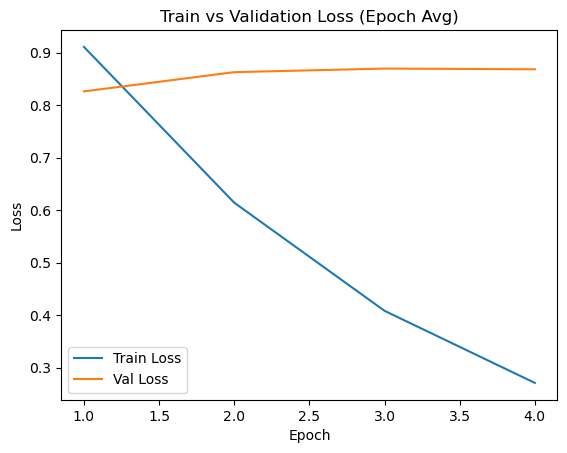

In [105]:
import matplotlib.pyplot as plt
import numpy as np

logs = trainer.state.log_history

# step 단위 train loss만 필터링
train_step_losses = [x for x in logs if 'loss' in x]

# epoch별 평균 계산
train_loss_by_epoch = []
current_epoch = -1
epoch_losses = []

for entry in train_step_losses:
    epoch = int(entry['epoch'])  # epoch 번호
    if epoch != current_epoch:
        if epoch_losses:
            train_loss_by_epoch.append(np.mean(epoch_losses))  # 이전 epoch 평균 저장
        current_epoch = epoch
        epoch_losses = []
    epoch_losses.append(entry['loss'])

# 마지막 epoch 평균 추가
if epoch_losses:
    train_loss_by_epoch.append(np.mean(epoch_losses))

# val_loss는 이미 epoch 단위
val_loss = [x['eval_loss'] for x in logs if 'eval_loss' in x]

# epoch별로 맞춰서 길이 맞추기
min_len = min(len(train_loss_by_epoch), len(val_loss))
train_loss_by_epoch = train_loss_by_epoch[:min_len]
val_loss = val_loss[:min_len]

# 그래프
plt.plot(range(1, min_len+1), train_loss_by_epoch, label='Train Loss')
plt.plot(range(1, min_len+1), val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Train vs Validation Loss (Epoch Avg)')
plt.show()

- train loss는 감소추세에 있으나, validation loss는 소폭 상승상태로 수렴하였다.(경미한 과적합?)

#### 정성평가

In [40]:
from transformers import pipeline

# 기존 모델 vs 새 모델 응답 비교
generator_old = pipeline('text-generation', model='models/output_1_SFT',     tokenizer=tokenizer)
generator_new = pipeline('text-generation', model='models/output_1_SFT_new', tokenizer=tokenizer)

generation_args = dict(
    num_beams=4,
    repetition_penalty=2.0,
    no_repeat_ngram_size=4,
    eos_token_id=375, # \n
    max_new_tokens=64,
    do_sample=True,
    top_k=50, #상위 50개 토큰 후보
    top_p=0.90, #누적확률 90%까지 후보
    temperature=0.7, #자연스러운 응답
    early_stopping=True
)

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = ['친구와 헤어지게 되어 슬퍼.']
list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt' : tmp}) for tmp in list_prompt]

for prompt in list_prompt:
    result_old = generator_old(prompt, **generation_args)[0]['generated_text']
    result_new = generator_new(prompt, **generation_args)[0]['generated_text']

    print(f"질문: {prompt}")
    print(f"[기존 모델] {result_old}")
    print(f"[새 모델]   {result_new}")
    print()

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


질문: ### Instruction(명령어):
친구와 헤어지게 되어 슬퍼.

### Response(응답):
[기존 모델] ### Instruction(명령어):
친구와 헤어지게 되어 슬퍼.

### Response(응답):'저는 인공지능 어시스턴트이기 때문에 감정을 느끼지는 않습니다. 하지만 친구와 헤어진 후 슬픔과 아픔을 느끼는 것은 자연스러운 일입니다. 그러나 이러한 감정을 극복하기 위해서는 다음과 같은 방법이 있을 수 있습니다.\n\n1. 친구나 가족과 함께 시간을 보내기: 친구나 가족들과 함께 시간을 보내는 것이 좋
[새 모델]   ### Instruction(명령어):
친구와 헤어지게 되어 슬퍼.

### Response(응답):그렇게 마음이 아프다면, 친구나 가족과 이야기를 나눠보는 것도 좋은 방법입니다. 함께 시간을 보내거나 취미활동 등을 통해 새로운 사람들을 만나보는 것도 도움이 될 수 있습니다. 또한, 친구나 가족에게 진심어린 말을 전하는 것도 큰 위안이 될 수 있습니다.郎)원장과의 대화를 통해 어려운 상황을 극복할 수 있을 것입니다.郎



- 기존 모델:"'저는 인공지능 어시스턴트이기 때문에 감정을 느끼지는 않습니다. 하지만 친구와 헤어진 후 슬픔과 아픔을 느끼는 것은 자연스러운 일입니다. 그러나 이러한 감정을 극복하기 위해서는 다음과 같은 방법이 있을 수 있습니다.\n\n1. 친구나 가족과 함께 시간을 보내기: 친구나 가족들과 함께 시간을 보내는 것이 좋"
- SFT 모델:"그렇게 마음이 아프다면, 친구나 가족과 이야기를 나눠보는 것도 좋은 방법입니다. 함께 시간을 보내거나 취미활동 등을 통해 새로운 사람들을 만나보는 것도 도움이 될 수 있습니다. 또한, 친구나 가족에게 진심어린 말을 전하는 것도 큰 위안이 될 수 있습니다."

-> SFT 모델에서 서두에 불필요한 말을 생략하고 질문과 좀 더 매끄럽게 이어지는 대화를 구사함

#### 정량평가

In [108]:
!pip install python-mecab-ko
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 89.9 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [python-mecab-ko]dic]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 12.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [konlpy]2m2/3 [konlpy]


In [111]:
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.0 MB/s eta 0:00:00


In [42]:
from mecab import MeCab

mecab = MeCab()

In [113]:
import logging
import warnings

# transformers 경고 suppress
logging.getLogger("transformers").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

# NLTK 로그 suppress
logging.getLogger("nltk").setLevel(logging.ERROR)

In [121]:
from nltk.translate.meteor_score import meteor_score
import nltk
nltk.download('wordnet')

def korean_tokenize(text):
    return mecab.morphs(text)

def evaluate_meteor(generator, prompts, labels, generation_args):
    scores = []
    for prompt, label in zip(prompts, labels):
        # 프롬프트 포맷팅
        input_text = PROMPT_DICT['prompt_input'].format_map({'prompt': prompt})
        # 응답 생성
        generated  = generator(input_text, **generation_args)[0]['generated_text']
        generated  = generated.replace(input_text, '').strip()
        # METEOR 계산
        gen_tokens = korean_tokenize(generated)
        ref_tokens = korean_tokenize(label)
        score      = meteor_score([ref_tokens], gen_tokens)
        scores.append(score)
    return sum(scores) / len(scores)

# test 데이터 추출
test_prompts = [clean_list_data_dict_sft[i]['prompt']     for i in test_data.indices]
test_labels  = [clean_list_data_dict_sft[i]['completion']     for i in test_data.indices]
print(f"test 샘플 수: {len(test_prompts)}개")

# METEOR 평가
score_new = evaluate_meteor(generator_new, test_prompts[:100], test_labels[:100], generation_args) #100개만 평가
print(f"METEOR Score: {score_new:.4f}")

[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


test 샘플 수: 1113개
METEOR Score: 0.4028


METEOR Score  
- 기존 모델: *(test dataset을 따로 나누지 않았음. 데이터를 나누고 재학습 필요) 
- SFT: 0.4028 (test_data 중 100개만 평가)
  - 일반적인 기준으로 0.4 이상의 경우 "매우 좋음"으로 평가됨

In [125]:
torch.cuda.empty_cache()

### RF (Reward Model)

In [ ]:
#SFT 모델의 출력 결과를 Reward model이 받아 어떻게 처리하게 되는지 잠시 생각해봅시다. 여기서 Reward model로 GPT2를 사용하는 이유가 무엇일까요?

In [7]:
from chatgpt.dataset import RewardDataset #chosen / rejected 문장 쌍을 토크나이징하고 학습용 텐서로 변환
from chatgpt.models.base import RewardModel
from chatgpt.trainer.strategies import NaiveStrategy
from chatgpt.trainer.rm import RewardModelTrainer

from transformers.models.gpt2.configuration_gpt2 import GPT2Config
from transformers.models.gpt2.modeling_gpt2 import GPT2Model

import torch.nn as nn

import random

In [10]:
class GPTRM_custom(RewardModel):

    def __init__(self,
                 pretrained: Optional[str] = None,
                 config: Optional[GPT2Config] = None,
                 checkpoint: bool = False,
                 lora_rank: int = 0,
                 lora_train_bias: str = 'none',
                 tokenizer=None) -> None:
        if pretrained is not None:
            model = GPT2Model.from_pretrained(pretrained)
            model.resize_token_embeddings(len(tokenizer))
        elif config is not None:
            model = GPT2Model(config)
        else:
            model = GPT2Model(GPT2Config())
        if checkpoint:
            model.gradient_checkpointing_enable()

        value_head = nn.Linear(model.config.n_embd, 1) # ✅model.config.n_embd: GPT-2의 내부 은닉 상태 벡터의 차원(예: 768, 1024 등). 1: 최종적으로 하나의 보상 값(스칼라)을 출력하기 위한 차원.
        super().__init__(model, value_head, lora_rank, lora_train_bias)

        if pretrained is not None:
            self.model = model
            self.pretrained = pretrained


    def save_pretrained(self, dir):
        if self.pretrained is not None:
            self.model.save_pretrained(dir)

In [11]:
model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>',
    unk_token='<unk>', pad_token='</s>',
    padding_side="right", model_max_length=512,
)

with NaiveStrategy().model_init_context():
        model = GPTRM_custom(pretrained='skt/kogpt2-base-v2', lora_rank=0, tokenizer=tokenizer).cuda()

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
lm_head.weight                          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
import json

with open('KoChatGPT/data_kochatgpt/kochatgpt_2_RM_new.jsonl', "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

total_data_ranking2chosen = []
for tmp in list_data_dict:
    one_data_ranking2chosen = []

    # A와 B, A와 C, B와 C를 비교
    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][0] < tmp['ranking'][1]:
        data['chosen'] = tmp['completion_0']
        data['rejected'] = tmp['completion_1']
    else:
        data['chosen'] = tmp['completion_1']
        data['rejected'] = tmp['completion_0']
    one_data_ranking2chosen.append(data)

    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][0] < tmp['ranking'][2]:
        data['chosen'] = tmp['completion_0']
        data['rejected'] = tmp['completion_2']
    else:
        data['chosen'] = tmp['completion_2']
        data['rejected'] = tmp['completion_0']
    one_data_ranking2chosen.append(data)

    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][1] < tmp['ranking'][2]:
        data['chosen'] = tmp['completion_1']
        data['rejected'] = tmp['completion_2']
    else:
        data['chosen'] = tmp['completion_2']
        data['rejected'] = tmp['completion_1']
    one_data_ranking2chosen.append(data)



    total_data_ranking2chosen.extend(one_data_ranking2chosen)

print('before data num: %d'%(len(list_data_dict)))
print('after  data num: %d'%(len(total_data_ranking2chosen)))
print('data example: \n%s'%total_data_ranking2chosen[0])

before data num: 10140
after  data num: 30420
data example: 
{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?', 'chosen': '번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.', 'rejected': 'Allow me to answer your question. I know that you are curious about me.'}


In [15]:
'''
# RM의 loss 계산
class PairWiseLoss(nn.Module):

    def forward(self, chosen_reward: torch.Tensor, reject_reward: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(chosen_reward - reject_reward) #선택된 샘플이 거부된 샘플보다 더 좋은 결과를 낼 확률로 해석
        log_probs = torch.log(probs) #선택된 샘플이 거부된 샘플보다 더 좋은 결과를 내는 log 확률을 최대화하는 방향으로 작동함
        loss = -log_probs.mean()
        return loss
'''

'\n# RM의 loss 계산\nclass PairWiseLoss(nn.Module):\n\n    def forward(self, chosen_reward: torch.Tensor, reject_reward: torch.Tensor) -> torch.Tensor:\n        probs = torch.sigmoid(chosen_reward - reject_reward) #선택된 샘플이 거부된 샘플보다 더 좋은 결과를 낼 확률로 해석\n        log_probs = torch.log(probs) #선택된 샘플이 거부된 샘플보다 더 좋은 결과를 내는 log 확률을 최대화하는 방향으로 작동함\n        loss = -log_probs.mean()\n        return loss\n'

-> 데이터셋의 ranking이 신뢰할만한지 불확실하기 때문에 첫번째 방식으로 진행

In [16]:
import random
random.seed(230319)
random.shuffle(total_data_ranking2chosen)
print(total_data_ranking2chosen[0])

{'prompt': '장면은 언제 친일인명사전 후보 명단으로 올라갔어', 'chosen': '요? 친일인명사전 후보 명단은 2020년 8월 28일에 올라갔습니다.', 'rejected': '가는 것 같다 장면은 언제 친일인명사전 후보 명단으로 올라갔어 가는 것 같다 장면은 언제 친일인명사전 후보 명단으로 개인들이 개발한 것 같다 장면은 언제 친일인명사전 후보 명단으로 개인들이 개발한 것 같다 장면은 언제 친일인명사전 후보 명단으'}


In [17]:
total_size = len(total_data_ranking2chosen)
val_size   = int(total_size * 0.1)
test_size = int(total_size * 0.1)

train_data = total_data_ranking2chosen[val_size+test_size:]
eval_data = total_data_ranking2chosen[:val_size]
test_data  = total_data_ranking2chosen[val_size:val_size+test_size]

print(len(train_data))
print(len(eval_data))

train_dataset = RewardDataset(train_data, tokenizer, 512)
eval_dataset = RewardDataset(eval_data, tokenizer, 512)

24336
3042


  0%|          | 0/24336 [00:00<?, ?it/s]

  0%|          | 0/3042 [00:00<?, ?it/s]

In [18]:
idx = 1
print('#'*70)
print('## prompt ##')
print(train_data[idx]['prompt'])
print('#'*70)
print('## chosen ##')
print(train_data[idx]['chosen'])
print('#'*70)
print('## rejected ##')
print(train_data[idx]['rejected'])

######################################################################
## prompt ##
한남대교가 만들어진 해는?
######################################################################
## chosen ##
한남대교는 1982년에 완공되었습니다.
######################################################################
## rejected ##
한남대교는 1972년에 만들어졌습니다.


Train epoch:   0%|          | 0/4 [00:00<?, ?it/s]

Train step of epoch 0:   0%|          | 0/6084 [00:00<?, ?it/s]

Train step of epoch 1:   0%|          | 0/6084 [00:00<?, ?it/s]

Train step of epoch 2:   0%|          | 0/6084 [00:00<?, ?it/s]

Train step of epoch 3:   0%|          | 0/6084 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

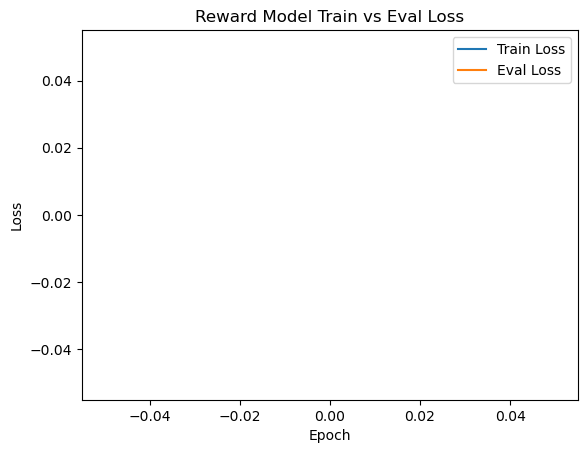

In [20]:
history = {'train_loss': [], 'eval_loss': []}

class RewardModelTrainerWithHistory(RewardModelTrainer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.history = {'train_loss': [], 'eval_loss': []}

    def train_epoch(self, *args, **kwargs):
        train_loss = super().train_epoch(*args, **kwargs)
        self.history['train_loss'].append(train_loss)
        return train_loss

    def eval_epoch(self, *args, **kwargs):
        eval_loss = super().eval_epoch(*args, **kwargs)
        self.history['eval_loss'].append(eval_loss)
        return eval_loss

# 사용
trainer = RewardModelTrainerWithHistory(
    model=model,
    strategy=NaiveStrategy(),
    optim=torch.optim.Adam(model.parameters(), lr=5e-5),
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    batch_size=4,
    max_epochs=4
)

trainer.fit(use_lora=0)
model.save_pretrained('models/output_2_RM_new')

In [30]:
import matplotlib.pyplot as plt
import numpy as np

logs = trainer.state.log_history

# step 단위 train loss만 필터링
train_step_losses = [x for x in logs if 'loss' in x]

# epoch별 평균 계산
train_loss_by_epoch = []
current_epoch = -1
epoch_losses = []

for entry in train_step_losses:
    epoch = int(entry['epoch'])  # epoch 번호
    if epoch != current_epoch:
        if epoch_losses:
            train_loss_by_epoch.append(np.mean(epoch_losses))  # 이전 epoch 평균 저장
        current_epoch = epoch
        epoch_losses = []
    epoch_losses.append(entry['loss'])

# 마지막 epoch 평균 추가
if epoch_losses:
    train_loss_by_epoch.append(np.mean(epoch_losses))

# val_loss는 이미 epoch 단위
val_loss = [x['eval_loss'] for x in logs if 'eval_loss' in x]

# epoch별로 맞춰서 길이 맞추기
min_len = min(len(train_loss_by_epoch), len(val_loss))
train_loss_by_epoch = train_loss_by_epoch[:min_len]
val_loss = val_loss[:min_len]

# 그래프
plt.plot(range(1, min_len+1), train_loss_by_epoch, label='Train Loss')
plt.plot(range(1, min_len+1), val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Reward Model Train vs Validation Loss (Epoch Avg)')
plt.show()

AttributeError: 'RewardModelTrainerWithHistory' object has no attribute 'state'

In [21]:
def inference_RM(input_text):
    input_ids = tokenizer.encode(input_text, return_tensors='pt').cuda()
    output = model(input_ids)
    output_reward = output.cpu().detach().numpy()[0]

    print('input: %s\nreward score: %.1f'%(input_text, output_reward))

    return output_reward

input_text = '인공지능은 똥멍청이 입니다'
output_reward = inference_RM(input_text=input_text)

input: 인공지능은 똥멍청이 입니다
reward score: -1.6


In [22]:
input_text = '인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.'

output_reward = inference_RM(input_text=input_text)

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.
reward score: -1.5


In [31]:
input_text = '인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다.'

output_reward = inference_RM(input_text=input_text)

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다.
reward score: -1.6


-> 음수값만 내놓는 문제 발생. 왜일까??

#### 정성평가

In [28]:
generator = transformers.pipeline('text-generation', model='models/output_1_SFT_new', tokenizer=tokenizer)

generation_args = dict(
    num_beams=4,
    repetition_penalty=2.0,
    no_repeat_ngram_size=4,
    eos_token_id=375, # \n
    max_new_tokens=64,
    do_sample=True,
    top_k=50, #상위 50개 토큰 후보
    top_p=0.90, #누적확률 90%까지 후보
    temperature=0.7, #자연스러운 응답
    early_stopping=True
)

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = ['친구와 헤어지게 되어 슬퍼.']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt' : tmp}) for tmp in list_prompt]

list_result = generator(list_prompt, **generation_args)
for prompt, result in zip(list_prompt, list_result):
    print()
    print((result[0]['generated_text']))

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Passing `generation_config` together with generation-related arguments=({'top_p', 'top_k', 'repetition_penalty', 'temperature', 'do_sample', 'num_beams', 'no_repeat_ngram_size', 'early_stopping', 'max_new_tokens', 'eos_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



### Instruction(명령어):
친구와 헤어지게 되어 슬퍼.

### Response(응답):그것은 정말 슬픈 일입니다. 그 이유는 매우 복잡하고 다양할 수 있기 때문입니다. n n첫째, 이별은 매우 아픈 일입니다. 이별은 서로 다른 길을 가야하는 상황이기 때문에 마음이 아프고 슬프게 느껴질 수 있습니다. n n둘째, 이별은 서로에게 큰 상처를 줄 수 있는 일이기 때문에 감정이 더욱


- SFT 결과: "그렇게 마음이 아프다면, 친구나 가족과 이야기를 나눠보는 것도 좋은 방법입니다. 함께 시간을 보내거나 취미활동 등을 통해 새로운 사람들을 만나보는 것도 도움이 될 수 있습니다. 또한, 친구나 가족에게 진심어린 말을 전하는 것도 큰 위안이 될 수 있습니다."
- RM 결과: "그것은 정말 슬픈 일입니다. 그 이유는 매우 복잡하고 다양할 수 있기 때문입니다. n n첫째, 이별은 매우 아픈 일입니다. 이별은 서로 다른 길을 가야하는 상황이기 때문에 마음이 아프고 슬프게 느껴질 수 있습니다. n n둘째, 이별은 서로에게 큰 상처를 줄 수 있는 일이기 때문에 감정이 더욱"  

->SFT는 질문자에게 솔루션을 제공하고  
->RM은 질문자의 슬프고, 아픈 감정을 분석하는 응답을 하고있다.  
사용자에따라 선호하는 응답의 방향이 다를 것 같다. 개인적 선호는 SFT

#### 정량평가

In [38]:
from nltk.translate.meteor_score import meteor_score
import nltk
nltk.download('wordnet')

def korean_tokenize(text):
    return mecab.morphs(text)

def evaluate_meteor(generator, prompts, labels, generation_args):
    scores = []
    for prompt, label in zip(prompts, labels):
        # 프롬프트 포맷팅
        input_text = PROMPT_DICT['prompt_input'].format_map({'prompt': prompt})
        # 응답 생성
        generated  = generator(input_text, **generation_args)[0]['generated_text']
        generated  = generated.replace(input_text, '').strip()
        # METEOR 계산
        gen_tokens = korean_tokenize(generated)
        ref_tokens = korean_tokenize(label)
        score      = meteor_score([ref_tokens], gen_tokens)
        scores.append(score)
    return sum(scores) / len(scores)


[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [43]:
# test 데이터 추출
test_prompts = [item['prompt'] for item in total_data_ranking2chosen]
test_labels  = [item['chosen'] for item in total_data_ranking2chosen]
print(f"test 샘플 수: {len(test_prompts)}개")

# METEOR 평가
score_new = evaluate_meteor(generator, test_prompts[:100], test_labels[:100], generation_args) #100개만 평가
print(f"METEOR Score: {score_new:.4f}")

Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


test 샘플 수: 30420개


Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

METEOR Score: 0.3302


METEOR Score

- SFT: 0.4028 (test_data 중 100개만 평가) 일반적인 기준으로 0.4~0.5의 경우 정답에 가까운 응답이며 "매우 좋음"으로 평가됨.
- RM: 0.3302 (test_data 중 100개만 평가) 일반적인 기준으로 0.3~0.4의 경우 의미와 표현이 모두 유사하며 "좋음"으로 평가됨.
> SFT는 질문에 정답 응답을 모방하는 방식으로 학습되는 반면, RM은 학습방식이 두 응답 중 어느것이 더 나은지 비교하는 것으로 텍스트 생성 모델이 아님.  
> METEOR는 생성된 텍스트와 정답 텍스트를 비교하는 방식으로 SFT 모델이 점수가 더 높을 수 밖에 없음

### PPO (Proximal Policy Optimization)

 - actor모델은 1단계 SFT 모델을, critic모델은 2단계 RM 모델을 사용한다

In [44]:
from chatgpt.models.gpt import GPTActor, GPTCritic
from chatgpt.trainer import PPOTrainer

from copy import deepcopy

In [45]:
with NaiveStrategy().model_init_context():
    actor = GPTActor(pretrained='models/output_1_SFT_new', lora_rank=0).to(torch.cuda.current_device())
    critic = GPTCritic(pretrained='models/output_2_RM_new', lora_rank=0).to(torch.cuda.current_device())
    tokenizer = PreTrainedTokenizerFast.from_pretrained(
        'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>',
        unk_token='<unk>', pad_token='</s>',
        padding_side="right", model_max_length=512,
    )
    initial_model = deepcopy(actor)
    reward_model = RewardModel(deepcopy(critic.model), deepcopy(critic.value_head)).to(torch.cuda.current_device())

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [46]:
actor_optim = torch.optim.Adam(actor.parameters(), lr=5e-6)
critic_optim = torch.optim.Adam(critic.parameters(), lr=5e-6)

In [47]:
(actor, actor_optim), (critic, critic_optim), reward_model, initial_model = NaiveStrategy().prepare(
    (actor, actor_optim), (critic, critic_optim), reward_model, initial_model)

In [48]:
with open('KoChatGPT/data_kochatgpt/kochatgpt_3_PPO_new.jsonl', "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)
    list_prompt = [tmp['prompt'] for tmp in list_data_dict]

def tokenize_fn(texts):
    batch = tokenizer(texts, return_tensors='pt', max_length=96, padding=True, truncation=True)
    return {k: v.cuda() for k, v in batch.items()}

In [49]:
print(tokenize_fn('It takes something more than intelligence to act intelligently.'))

{'input_ids': tensor([[47311, 10448, 19008,  9792, 11780, 11308, 30190, 10929, 11849, 21663,
         44389,  9574, 13799,   458, 14308, 12778, 22469, 20938, 44696,   458,
         13799,   458, 14308, 12778, 11756, 18944,   389]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1]], device='cuda:0')}


In [50]:
trainer = PPOTrainer(NaiveStrategy(),
                     actor,
                     critic,
                     reward_model,
                     initial_model,
                     actor_optim,
                     critic_optim,
                     max_epochs=5,
                     train_batch_size=8,
                     tokenizer=tokenize_fn,
                     max_length=128,
                     do_sample=True,
                     temperature=0.7,
                     top_k=50,
                     top_p=0.9,
                     pad_token_id=tokenizer.pad_token_id,
                     eos_token_id=tokenizer.eos_token_id)

In [52]:
#학습진행
trainer.fit(list_prompt,
            num_episodes=10,
            max_timesteps=3,
            update_timesteps=3)

actor.model.save_pretrained('models/output_3_PPO_new')

Episode [1/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [2/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [3/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [4/5]:   0%|          | 0/3 [00:00<?, ?it/s]

...

Train epoch [2/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [3/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [4/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [5/5]:   0%|          | 0/3 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

-> SFT, RM 그리고 PPO 학습이 모두 완료  
-> RLHF가 적용된 koGPT-2의 생성능력을 확인해볼까요?

#### 정성평가

In [56]:
def generation(input_text, model):
    input_ids = tokenizer.encode(input_text, return_tensors='pt').to(
        torch.cuda.current_device())
    outputs = model.generate(input_ids,
                             max_length=150,
                             do_sample=True,
                             top_k=50,
                             top_p=0.90,
                             temperature=0.7, #추가
                             num_return_sequences=1)
    output = tokenizer.batch_decode(outputs[0], skip_special_tokens=True)[0]
    print()
    print(output)
    return output

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = [
    '친구와 헤어지게 되어 슬퍼.']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt': tmp}) for tmp in list_prompt]

for input_text in list_prompt:
    output = generation(input_text, actor)


### Instruction(명령어):
친구와 헤어지게 되어 슬퍼.

### Response(응답):그렇다면 그 상황을 어떻게 해결할지 생각해보세요. 그 상황에서는 서로의 감정을 이해하고 공감하며 헤어짐을 명확히 인정해야 합니다. 그리고 이별 후에는 서로를 위해 새로운 관계를 구축해야 합니다. 그래야 서로 더 잘 이해하고 이별할 수 있을 것입니다. 그 때는 감정을 공감하고 이별할 수 있는 방법을 찾아보는 것도 좋은 방법입니다. 그리고 이별 후에도 서로의 마음을 치유할 수 있도록 지속적인 노력을 기울여 볼 수 있습니다. 이별은 어려운 상황일 수 있지만, 그 경험이 우리에게 큰 도움이 될 것입니다.法律)ia n n다시 한 번 이전의 상황이나 감정에 대한 피드백을 제공해주시면 보다 정확하고 유용한 답


#### 종합결과
- 정성평가 : 기존 < RM < SFT < PPO
  > - 기존: (불필요한말 포함) "저는 인공지능 어시스턴트이기 때문에 감정을 느끼지는 않습니다. 하지만 친구와 헤어진 후 슬픔과 아픔을 느끼는 것은 자연스러운 일입니다. 그러나 이러한 감정을 극복하기 위해서는 다음과 같은 방법이 있을 수 있습니다.\n\n1. 친구나 가족과 함께 시간을 보내기: 친구나 가족들과 함께 시간을 보내는 것이 ..."  
  > - RM: (감정 분석) "그것은 정말 슬픈 일입니다. 그 이유는 매우 복잡하고 다양할 수 있기 때문입니다. n n첫째, 이별은 매우 아픈 일입니다. 이별은 서로 다른 길을 가야하는 상황이기 때문에 마음이 아프고 슬프게 느껴질 수 있습니다. n n둘째, 이별은 서로에게 큰 상처를 줄 수 있는 일이기 때문에 감정이 더욱 ..."
  > - SFT: (솔루션 제공) "그렇게 마음이 아프다면, 친구나 가족과 이야기를 나눠보는 것도 좋은 방법입니다. 함께 시간을 보내거나 취미활동 등을 통해 새로운 사람들을 만나보는 것도 도움이 될 수 있습니다. 또한, 친구나 가족에게 진심어린 말을 전하는 것도 큰 위안이 될 수 있습니다."
  > - PPO: (스스로 생각해볼 수 있도록 유도) "그렇다면 그 상황을 어떻게 해결할지 생각해보세요. 그 상황에서는 서로의 감정을 이해하고 공감하며 헤어짐을 명확히 인정해야 합니다. 그리고 이별 후에는 서로를 위해 새로운 관계를 구축해야 합니다. 그래야 서로 더 잘 이해하고 이별할 수 있을 것입니다. 그 때는 감정을 공감하고 이별할 수 있는 방법을 찾아보는 것도 좋은 방법입니다. 그리고 이별 후에도 서로의 마음을 치유할 수 있도록 지속적인 노력을 기울여 볼 수 있습니다. 이별은 어려운 상황일 수 있지만, 그 경험이 우리에게 큰 도움이 될 것입니다."
- 정량평가 : RM(0.3302) < SFT(0.4028) *PPO는 label이 없음. SFT의 completion을 label로 매칭해볼 수 있을 듯  

- 회고
  - 1. 추가로 고려해볼 사항. 정성적인 평가로는 PPO가 가장 우세하나, 정량평가 방법이 마땅하지 않다. SFT의 completion을 label로 매칭하는 평가가 적합할까??